 Trabalho Prático de Programação e Algoritmia:
 Alexandre Volozhenin 119098,
 Pedro Sousa 119688,
 Guilherme Almeida 120069.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Leitura do ficheiro

In [2]:
filename = "Exoplanets.csv"
Exo = pd.read_csv(filename)
Exo.head()

,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


## 1. Qual o tipo de exoplanetas mais comum, e a qual do sistema solar é mais parecido?

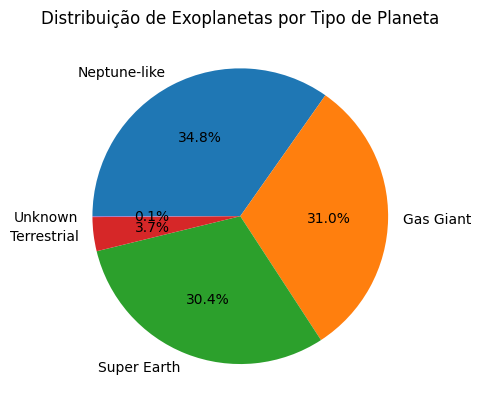

In [3]:
planet_type_counts = Exo['planet_type'].value_counts()
plt.pie(planet_type_counts, labels=planet_type_counts.index, autopct='%1.1f%%', startangle = 180, counterclock= False)
plt.title('Distribuição de Exoplanetas por Tipo de Planeta')
plt.show()

Como é possível observar, os exoplanetas na sua maioria estão quase igualmente divididos em três grandes categorias. Neptune Like, Gas Giants e Super Earths, compondo estes 3 tipos 96.2% do total.
E também se observa que apenas 0.1% do total é um tipo que não tem as características de um existente.

## 2. O quão comum são earth like planets, e quais destes são potencialmente habitáveis?   

In [4]:
earth_like_planets = Exo[(Exo['planet_type'] == 'Terrestrial') | (Exo['planet_type'] == 'Super Earth')]
# Considerou-se earth like planets aqueles que são do tipo Terrestrial ou Super Earths
num_earth_like = len(earth_like_planets) #contagem do número de earth like planets

total_planets = len(Exo) #contagem do numero total

percentage_earth_like = (num_earth_like / total_planets) * 100

print(f"Número de planetas semelhantes à Terra: {num_earth_like}")
print(f"Número total de planetas: {total_planets}")
print(f"Percentagem de planetas semelhantes à Terra: {percentage_earth_like:.2f}%")

#definição cientifica da gama de distância de um planeta à sua estrela para ter água no estado liquído

habitable_earth_like_planets = earth_like_planets[
    (earth_like_planets['orbital_radius'] >= 0.9) &
    (earth_like_planets['orbital_radius'] <= 1.5)
]

num_habitable_earth_like = len(habitable_earth_like_planets)
habitable_by_orbit = Exo[(Exo['orbital_radius'] >= 0.9) & (Exo['orbital_radius'] <= 1.5)]

print(f"Número de planetas semelhantes à Terra com raio orbital entre 0,9 e 1,5 UA: {num_habitable_earth_like}")
print(f"Total de candidatos na gama orbital: {len(habitable_by_orbit)}") #para qualquer tipo de planeta

Número de planetas semelhantes à Terra: 1790
Número total de planetas: 5250
Percentagem de planetas semelhantes à Terra: 34.10%
Número de planetas semelhantes à Terra com raio orbital entre 0,9 e 1,5 UA: 6
Total de candidatos na gama orbital: 209


É possível concluir que 34.10% dos planetas são parecidos com a terra quanto ao tipo de planetas, ou seja 34.10% dos planetas são Terrestrial ou Super Earth.
Porém destes 1790, apenas 6 deles estão no raio orbital da sua estrela que lhes permite ter água em estado liquido, algo crucial para a habitabilidade.

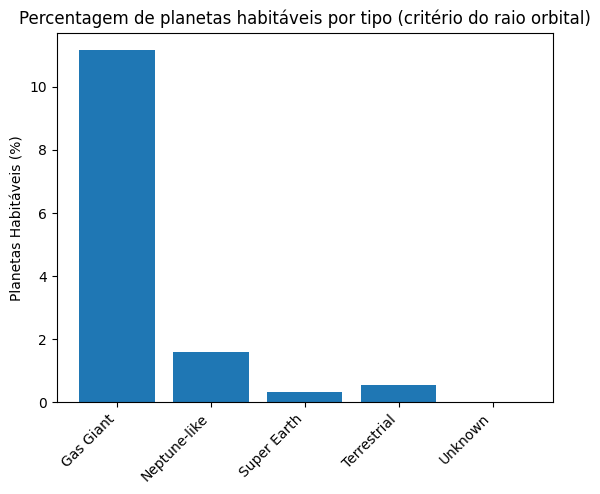

In [5]:
HAB_MIN = 0.9
HAB_MAX = 1.5

Exod = Exo.dropna(subset=['orbital_radius', 'planet_type'])

total_per_type = Exod['planet_type'].value_counts()

habitable = Exod[(Exod['orbital_radius'] >= HAB_MIN) & (Exod['orbital_radius'] <= HAB_MAX)]
habitable_per_type = habitable['planet_type'].value_counts()

summary = pd.DataFrame({
    'Total': total_per_type,
    'Habitável': habitable_per_type
}).fillna(0) #criação de dataframe com os valores relevantes


summary['% Habitável'] = (summary['Habitável'] / summary['Total']) * 100

plt.bar(summary.index, summary['% Habitável'])
plt.title('Percentagem de planetas habitáveis por tipo (critério do raio orbital)')
plt.ylabel('Planetas Habitáveis (%)')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--')
plt.show()

É possível observar que nos planetas Neptune-like ou Gas Giants existe uma maior percentagem de planetas que estão no raio orbital que permite água no estado liquido. Infelizmente, devido à sua natureza de atmosfera e diferenças à Terra, estes não seriam habitáveis.

## 3. A massa tem alguma correlação com o raio do planeta?

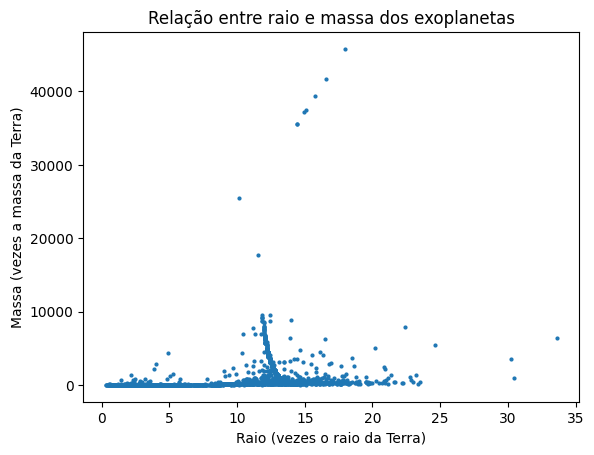

In [6]:

filtro_terra_raio = Exo[Exo.columns[8]] == "Earth"
filtro_jupiter_raio = Exo[Exo.columns[8]] == "Jupiter"
filtro_terra_massa = Exo[Exo.columns[6]] == "Earth"
filtro_jupiter_massa = Exo[Exo.columns[6]] == "Jupiter"

# Filtração dos raios e massas, em booleano

Terra_raio_multiplicador = Exo.loc[filtro_terra_raio,"radius_multiplier"]
Jupiter_raio_multiplicador = Exo.loc[filtro_jupiter_raio,"radius_multiplier"]
Terra_massa_multiplicador = Exo.loc[filtro_terra_massa,"mass_multiplier"]
Jupiter_massa_multiplicador = Exo.loc[filtro_jupiter_massa,"mass_multiplier"]

Massa_Jupiter = 318 # A massa do Jupiter é 318 vezes maior que a massa da Terra
Raio_Jupiter = 11.2 # O raio do Jupiter em relação com o raio da Terra

Jupiter_raio_multiplicador = Jupiter_raio_multiplicador * Raio_Jupiter
Jupiter_massa_multiplicador = Jupiter_massa_multiplicador * Massa_Jupiter

# Junção das séries

Raio_multiplicador = pd.concat([Terra_raio_multiplicador,Jupiter_raio_multiplicador])
Massa_multiplicador = pd.concat([Terra_massa_multiplicador,Jupiter_massa_multiplicador])

# Criação de um novo dataframe e retirar todos os valores NA

Dados = pd.DataFrame({"Raio": Raio_multiplicador, "Massa": Massa_multiplicador}).dropna()

Dados = Dados.sort_values(by=["Raio","Massa"],ascending=[True,False])
Dados = Dados.iloc[:-1] # Tirar o valor mais elevado, pois é outlier muito distante dos restantes pontos

plt.scatter(Dados["Raio"], Dados["Massa"], s = 4)
plt.xlabel("Raio (vezes o raio da Terra)")
plt.ylabel("Massa (vezes a massa da Terra)")
plt.title("Relação entre raio e massa dos exoplanetas")
plt.show()


Observando o gráfico, percebemos que não há uma correlação forte entre a massa e o raio dos exoplanetas. Isso fica evidente ao vermos, por exemplo, exoplanetas com raio 20 vezes maior que o da Terra, mas com massas próximas ao da Terra. Por outro lado, há planetas com raios cerca de 12,5 vezes maiores que o da Terra e com massas 10000 vezes maiores que da Terra. Esses contrastes indicam que a composição do exoplaneta — ou seja, o material de que é feito — desempenha um papel muito mais relevante na determinação da sua massa do que o seu tamanho.

## 4. Existe ligação entre o método de descoberta e o tipo de exoplaneta?


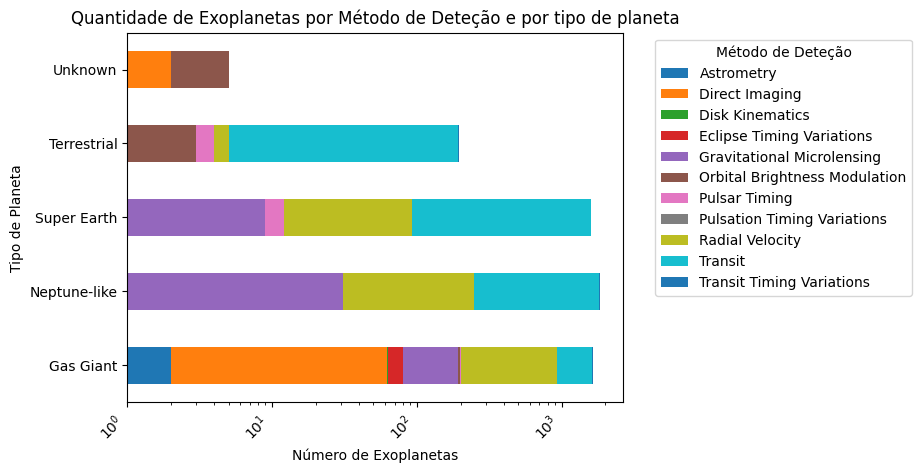

In [7]:
Exo_cleaned = Exo.dropna(subset=['detection_method', 'planet_type'])
count = Exo_cleaned.groupby(['planet_type', 'detection_method']).size()
grouped = count.unstack(fill_value=0) # colocação em formato tabela para ser possível dar plot

grouped.plot(kind='barh',stacked=True)
plt.title('Quantidade de Exoplanetas por Método de Deteção e por tipo de planeta')
plt.ylabel('Tipo de Planeta')
plt.xlabel('Número de Exoplanetas')
plt.xscale('log')  # Escala Logaritmica
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de Deteção', bbox_to_anchor=(1.05, 1), loc='upper left')
#bbox_to_anchor coloca a legenda fora do gráfico
#plt.grid(axis='y', linestyle='--')
plt.show()

Nota: Foi utilizado o ChatGTP para receber exemplos e perceber melhor o uso da função unstack.  Através da seguinte prompt:

"Explica e apresenta exemplos da função unstack da biblioteca pandas em python."

Pelo gráfico, é possível observar que o método de Transit é de longe o mais comum para a descoberta de exoplanetas. Porém, também é possível ver que métodos como o Direct Imaging enquanto que muito utilizados para Gas Giants e Unknowns, não estão presentes nos outros tipos.

# 5. Como tem evoluído a descoberta dos planetas com o passar dos anos?

Text(0.5, 1.0, 'Número de exoplanetas descobertos por ano')

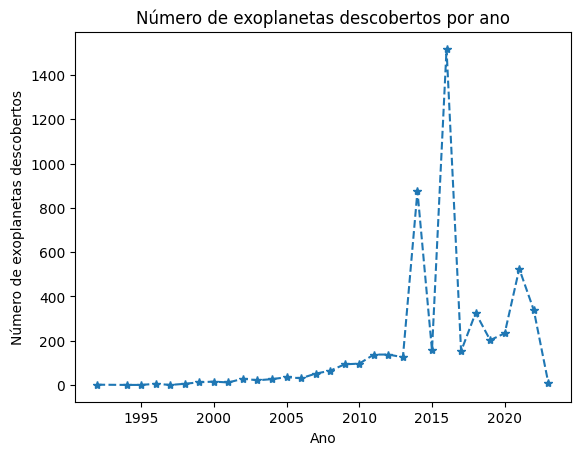

In [8]:
descobertas_ano = Exo.discovery_year
descobertas_ano = descobertas_ano.value_counts().sort_index()
# Contamos o número de planetas para todos os anos
# e ordenamos de modo a que fique por ordem crescente do ano

plt.plot(descobertas_ano,linestyle='--',marker='*')
plt.ylabel('Número de exoplanetas descobertos')
plt.xlabel('Ano')
plt.title('Número de exoplanetas descobertos por ano')

Observa-se que houve um pico de planetas descobertos em 2016, isto provavelmente deve-se ao facto de ter sido esse o ano em que foram recolhidos os dados do satélite Kepler. e a tendência geral é que o número de planetas descobertos tem vindo a aumentar.

Text(0.5, 1.0, 'Distância média dos exoplanetas à Terra por ano de descoberta')

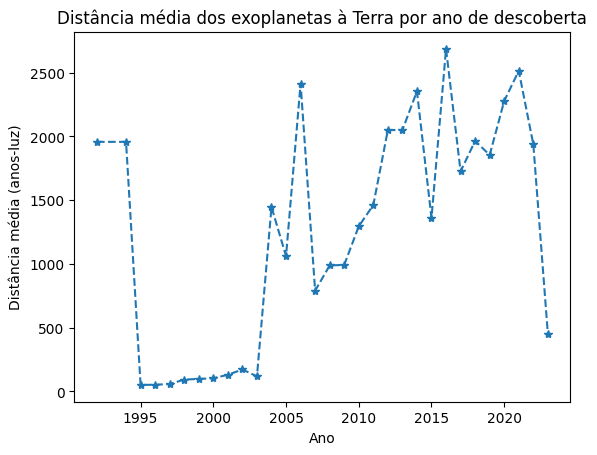

In [9]:
media_distancia = Exo.groupby('discovery_year')
media_distancia = media_distancia['distance'].mean()

# Primeiro agrupamos os planetas por ano de descoberta e filtramos só a informação referente à distância,
# depois calculamos a média das distâncias do exoplaneta à terra por ano.

plt.plot(media_distancia, linestyle='--', marker='*')
plt.ylabel('Distância média (anos-luz)')
plt.xlabel('Ano')
plt.title('Distância média dos exoplanetas à Terra por ano de descoberta')

Nos primeiros 2 anos foram detetados planetas consideravelmente distantes à Terra, depois a tendência foi de descoberta de planetas mais próximos. A partir de 2003 a distância média foi aumentando e atualmente a distância média oscila bastante em torno dos 2000 anos luz. Nos anos mais recentes verifica-se uma diminuição da distância explicada pela utilização do satélite TESS a partir de 2018 que busca por exoplanetas mais próximos da Terra

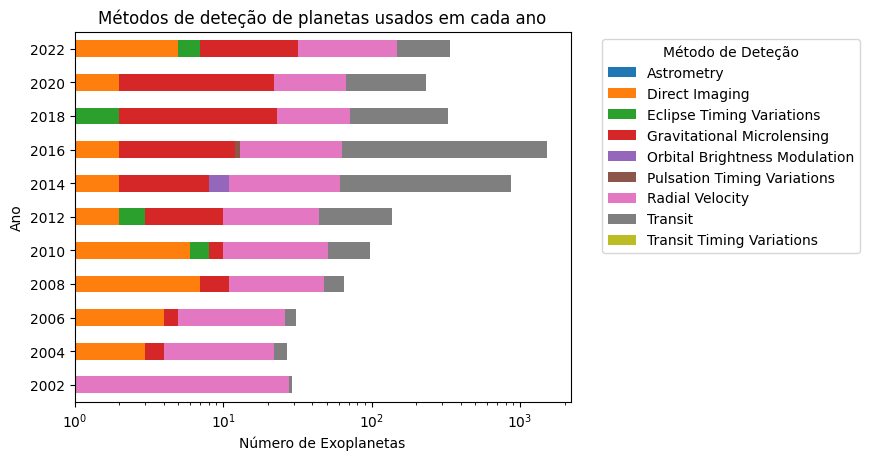

In [10]:
Exo_cleaned = Exo.dropna(subset=['detection_method'])
# retiramos as linhas onde não há informação do método de deteção.
anos_pares = Exo_cleaned['discovery_year']% 2 == 0
# estudamos apenas anos pares após 2000 para simplificar o gráfico
anos_apos_2000 = Exo_cleaned['discovery_year'] > 2000
Exo_cleaned = Exo_cleaned[anos_pares & anos_apos_2000]
count = Exo_cleaned.groupby(['discovery_year', 'detection_method']).size()
grouped = count.unstack(fill_value=0)

grouped.plot(kind='barh', stacked=True)
plt.title('Métodos de deteção de planetas usados em cada ano')
plt.ylabel('Ano')
plt.xlabel('Número de Exoplanetas')
plt.xscale('log')  # Escala Logaritmica
plt.legend(title='Método de Deteção', bbox_to_anchor=(1.05, 1), loc='upper left')
#bbox_to_anchor coloca a legenda fora do gráfico
#plt.grid(axis='y', linestyle='--')
plt.show()

Atualmente os métodos mais populares são 'Direct Imaging', 'Gravitational Microlensing', 'Radial Velocity' e 'Transit'.